In [3]:
import os
import openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score
from sklearn.model_selection import train_test_split
from xgboost.callback import EarlyStopping
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


In [2]:
d = openml.datasets.get_dataset(46356)
df, *_ = d.get_data()
df.head()

,Unnamed: 0,acc_status,acc_duration,credit_history,purpose,credit_amount,savings_acc,employment_time,installment_rate,gender,...,property,age,installment_plans,housing,num_credits_at_bank,job,num_people_maintenance,phone,foreigner,target
0,600,dm_0_to_200,7,credit_paid_so_far,radio_or_tv,2329,dm_less_100,less_one,1,female,...,real_estate,45,none,own,1,skilled_employee_or_official,1,no,yes,1
1,80,no_acc,24,credit_paid_so_far,radio_or_tv,5943,unknown_or_no_savings,less_one,1,female,...,car_or_other,44,none,own,2,skilled_employee_or_official,1,yes,yes,2
2,158,dm_0_to_200,24,credit_paid_so_far,car_new,3512,dm_100_to_500,four_to_seven,2,male,...,car_or_other,38,bank,own,2,skilled_employee_or_official,1,yes,yes,1
3,423,no_acc,21,delay_in_past_credit_payment,furniture_or_equipment,1591,dm_100_to_500,four_to_seven,4,male,...,real_estate,34,none,own,2,self_or_highly_qualified_employee,1,no,yes,1
4,747,dm_less_than_0,12,credit_paid_so_far,car_new,1274,dm_less_100,less_one,3,female,...,real_estate,37,none,own,1,unskilled_resident,1,no,yes,2


In [6]:
df = df.drop(columns=['Unnamed: 0'])

In [10]:
df['target'] = df['target'].replace({1: 1, 2: 0})

In [11]:
df

,acc_status,acc_duration,credit_history,purpose,credit_amount,savings_acc,employment_time,installment_rate,gender,other_debtors,...,property,age,installment_plans,housing,num_credits_at_bank,job,num_people_maintenance,phone,foreigner,target
0,dm_0_to_200,7,credit_paid_so_far,radio_or_tv,2329,dm_less_100,less_one,1,female,guarantor,...,real_estate,45,none,own,1,skilled_employee_or_official,1,no,yes,1
1,no_acc,24,credit_paid_so_far,radio_or_tv,5943,unknown_or_no_savings,less_one,1,female,none,...,car_or_other,44,none,own,2,skilled_employee_or_official,1,yes,yes,0
2,dm_0_to_200,24,credit_paid_so_far,car_new,3512,dm_100_to_500,four_to_seven,2,male,none,...,car_or_other,38,bank,own,2,skilled_employee_or_official,1,yes,yes,1
3,no_acc,21,delay_in_past_credit_payment,furniture_or_equipment,1591,dm_100_to_500,four_to_seven,4,male,none,...,real_estate,34,none,own,2,self_or_highly_qualified_employee,1,no,yes,1
4,dm_less_than_0,12,credit_paid_so_far,car_new,1274,dm_less_100,less_one,3,female,none,...,real_estate,37,none,own,1,unskilled_resident,1,no,yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_acc,18,critical_amount,radio_or_tv,6070,dm_less_100,greater_eq_seven,3,male,none,...,car_or_other,33,none,own,2,skilled_employee_or_official,1,yes,yes,1
996,no_acc,33,critical_amount,car_old,7253,dm_less_100,four_to_seven,3,male,none,...,car_or_other,35,none,own,2,self_or_highly_qualified_employee,1,yes,yes,1
997,dm_less_than_0,18,critical_amount,radio_or_tv,1880,dm_less_100,four_to_seven,4,male,none,...,life_insurance_or_savings_agreement,32,none,own,2,self_or_highly_qualified_employee,1,yes,yes,1
998,no_acc,48,credit_paid_so_far,business,4844,dm_less_100,unemployed,3,male,none,...,car_or_other,33,bank,rent,1,self_or_highly_qualified_employee,1,yes,yes,0


In [12]:
df.to_csv("credit_risk_data.csv", index=False, encoding="utf-8")

In [13]:
print(os.path.abspath("credit_risk_data.csv"))

c:\Users\Lenovo\Desktop\Home_Credit\credit_risk_data.csv


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Unnamed: 0              1000 non-null   int64 
 1   acc_status              1000 non-null   object
 2   acc_duration            1000 non-null   uint8 
 3   credit_history          1000 non-null   object
 4   purpose                 1000 non-null   object
 5   credit_amount           1000 non-null   int64 
 6   savings_acc             1000 non-null   object
 7   employment_time         1000 non-null   object
 8   installment_rate        1000 non-null   uint8 
 9   gender                  1000 non-null   object
 10  other_debtors           1000 non-null   object
 11  residence_time          1000 non-null   uint8 
 12  property                1000 non-null   object
 13  age                     1000 non-null   uint8 
 14  installment_plans       1000 non-null   object
 15  housi

In [4]:
df["target"].unique()

array([1, 2], dtype=uint8)

In [6]:
df.isnull().sum()

acc_status                0
acc_duration              0
credit_history            0
purpose                   0
credit_amount             0
savings_acc               0
employment_time           0
installment_rate          0
gender                    0
other_debtors             0
residence_time            0
property                  0
age                       0
installment_plans         0
housing                   0
num_credits_at_bank       0
job                       0
num_people_maintenance    0
phone                     0
foreigner                 0
target                    0
dtype: int64

In [7]:
num_cols = df.select_dtypes(include=['int64', 'uint8']).columns
print(num_cols)


Index(['acc_duration', 'credit_amount', 'installment_rate', 'residence_time',
       'age', 'num_credits_at_bank', 'num_people_maintenance', 'target'],
      dtype='object')


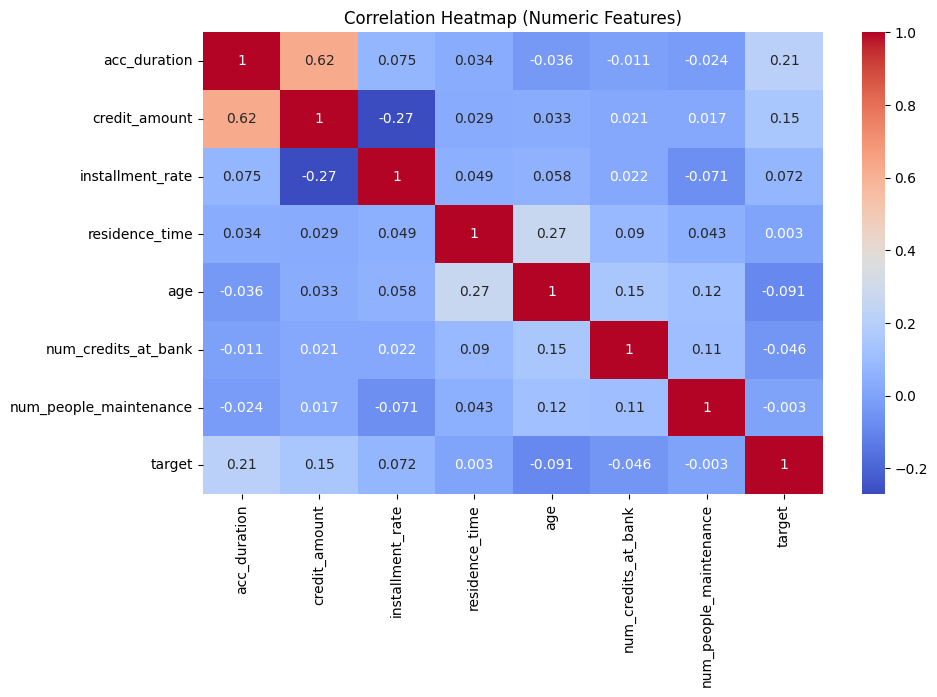

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


In [18]:
num_df = df.select_dtypes(include=['int64', 'uint8'])
corr_matrix = num_df.corr().abs()
high_corr = corr_matrix[(corr_matrix > 0.7) & (corr_matrix < 1.0)]

high_corr_pairs = [
    (col1, col2)
    for col1 in high_corr.columns
    for col2 in high_corr.index
    if not pd.isna(high_corr.loc[col2, col1])
]

High_Corr_ls = []

for i in range(len(high_corr_pairs)):
    if i%2==0:
        print(high_corr_pairs[i])
        High_Corr_ls.append(high_corr_pairs[i])

In [19]:
High_Corr_ls

[]

In [27]:
cat = df.select_dtypes(include='object')
len(cat.columns)


13

In [24]:
cat_cols = df.select_dtypes(include='object').columns
for i in cat_cols:
    print(df[i].unique)

<bound method Series.unique of 0         dm_0_to_200
1              no_acc
2         dm_0_to_200
3              no_acc
4      dm_less_than_0
            ...      
995            no_acc
996            no_acc
997    dm_less_than_0
998            no_acc
999            no_acc
Name: acc_status, Length: 1000, dtype: object>
<bound method Series.unique of 0                credit_paid_so_far
1                credit_paid_so_far
2                credit_paid_so_far
3      delay_in_past_credit_payment
4                credit_paid_so_far
                   ...             
995                 critical_amount
996                 critical_amount
997                 critical_amount
998              credit_paid_so_far
999              credit_paid_so_far
Name: credit_history, Length: 1000, dtype: object>
<bound method Series.unique of 0                 radio_or_tv
1                 radio_or_tv
2                     car_new
3      furniture_or_equipment
4                     car_new
                ...  

In [25]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    cv = cramers_v(df[col], df['target'])
    print(f"{col}: {cv:.3f}")


acc_status: 0.352
credit_history: 0.248
purpose: 0.183
savings_acc: 0.190
employment_time: 0.136
gender: 0.073
other_debtors: 0.082
property: 0.154
installment_plans: 0.113
housing: 0.135
job: 0.043
phone: 0.034
foreigner: 0.076


#ENCODING

In [34]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object'):
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [35]:
df_encoded

,acc_status,acc_duration,credit_history,purpose,credit_amount,savings_acc,employment_time,installment_rate,gender,other_debtors,...,property,age,installment_plans,housing,num_credits_at_bank,job,num_people_maintenance,phone,foreigner,target
0,0,7,0,7,2329,3,2,1,0,1,...,2,45,1,1,1,1,1,0,1,1
1,3,24,0,7,5943,4,2,1,0,2,...,0,44,1,1,2,1,1,1,1,0
2,0,24,0,1,3512,0,0,2,1,2,...,0,38,0,1,2,1,1,1,1,1
3,3,21,2,5,1591,0,0,4,1,2,...,2,34,1,1,2,0,1,0,1,1
4,2,12,0,1,1274,3,2,3,0,2,...,2,37,1,1,1,3,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,18,1,7,6070,3,1,3,1,2,...,0,33,1,1,2,1,1,1,1,1
996,3,33,1,2,7253,3,0,3,1,2,...,0,35,1,1,2,0,1,1,1,1
997,2,18,1,7,1880,3,0,4,1,2,...,1,32,1,1,2,0,1,1,1,1
998,3,48,0,0,4844,3,4,3,1,2,...,0,33,0,2,1,0,1,1,1,0


In [36]:
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']


In [37]:
y.value_counts()

target
1    700
0    300
Name: count, dtype: int64

In [44]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "F1": make_scorer(f1_score),
    "Accuracy": make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score)
}

print("Logistic Regression")
for metric_name, scorer in scorers.items():
    scores = cross_val_score(log_model, X, y, cv=cv, scoring=scorer)
    print(f"  {metric_name}: {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https:/

  F1: 0.738 ± 0.020


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https:/

  Accuracy: 0.662 ± 0.024


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https:/

  Precision: 0.808 ± 0.026


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
tree_model = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
scorers = {
    "F1": make_scorer(f1_score),
    "Accuracy": make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score)
}

print("Decision Tree")
for metric_name, scorer in scorers.items():
    scores = cross_val_score(tree_model, X, y, cv=cv, scoring=scorer)
    print(f"  {metric_name}: {scores.mean():.3f} ± {scores.std():.3f}")


Decision Tree
  F1: 0.747 ± 0.053
  Accuracy: 0.682 ± 0.041
  Precision: 0.834 ± 0.023


In [46]:
xgb_model = XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=150,
    eval_metric='logloss',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "F1": make_scorer(f1_score),
    "Accuracy": make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score)
}

print("XGBoost")
for metric_name, scorer in scorers.items():
    scores = cross_val_score(xgb_model, X, y, cv=cv, scoring=scorer)
    print(f"  {metric_name}: {scores.mean():.3f} ± {scores.std():.3f}")


XGBoost
  F1: 0.843 ± 0.016
  Accuracy: 0.768 ± 0.024
  Precision: 0.803 ± 0.022


# TRAIN TEST SPLIT

In [79]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

# Logistic Regression

In [83]:
log_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
log_model.fit(X_train, y_train)

y_train_pred_log = log_model.predict(X_train)
y_val_pred_log = log_model.predict(X_val)
y_test_pred_log = log_model.predict(X_test)

print("\n Logistic Regression Results")
print("Train  - Accuracy:", accuracy_score(y_train, y_train_pred_log),
      "Precision:", precision_score(y_train, y_train_pred_log),
      "F1:", f1_score(y_train, y_train_pred_log))

print("Valid. - Accuracy:", accuracy_score(y_val, y_val_pred_log),
      "Precision:", precision_score(y_val, y_val_pred_log),
      "F1:", f1_score(y_val, y_val_pred_log))

print("Test   - Accuracy:", accuracy_score(y_test, y_test_pred_log),
      "Precision:", precision_score(y_test, y_test_pred_log),
      "F1:", f1_score(y_test, y_test_pred_log))


 Logistic Regression Results
Train  - Accuracy: 0.7328125 Precision: 0.753199268738574 F1: 0.828140703517588
Valid. - Accuracy: 0.69375 Precision: 0.723404255319149 F1: 0.8063241106719368
Test   - Accuracy: 0.715 Precision: 0.7577639751552795 F1: 0.8106312292358804


# SVM 

In [85]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_train_pred_svm = svm_model.predict(X_train_scaled)
y_val_pred_svm = svm_model.predict(X_val_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)

print("\n SVM Results")

print(" Train Results:")
print("  Accuracy :", accuracy_score(y_train, y_train_pred_svm))
print("  Precision:", precision_score(y_train, y_train_pred_svm))
print("  F1 Score :", f1_score(y_train, y_train_pred_svm))

print("\n Validation Results:")
print("  Accuracy :", accuracy_score(y_val, y_val_pred_svm))
print("  Precision:", precision_score(y_val, y_val_pred_svm))
print("  F1 Score :", f1_score(y_val, y_val_pred_svm))

print("\n Test Results:")
print("  Accuracy :", accuracy_score(y_test, y_test_pred_svm))
print("  Precision:", precision_score(y_test, y_test_pred_svm))
print("  F1 Score :", f1_score(y_test, y_test_pred_svm))



 SVM Results
 Train Results:
  Accuracy : 0.8296875
  Precision: 0.9544235924932976
  F1 Score : 0.8672350791717418

 Validation Results:
  Accuracy : 0.65
  Precision: 0.8111111111111111
  F1 Score : 0.7227722772277227

 Test Results:
  Accuracy : 0.685
  Precision: 0.8468468468468469
  F1 Score : 0.749003984063745


# OVERFIT XGBOOST

In [53]:
xgb_model = XGBClassifier(
    max_depth=5, learning_rate=0.1, n_estimators=150,
    eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train, y_train)

y_train_pred = xgb_model.predict(X_train)

print("Train Results:")
print("  Accuracy:", accuracy_score(y_train, y_train_pred))
print("  Precision:", precision_score(y_train, y_train_pred))
print("  F1:", f1_score(y_train, y_train_pred))

y_val_pred = xgb_model.predict(X_val)
print("Validation Results:")
print("  Accuracy:", accuracy_score(y_val, y_val_pred))
print("  Precision:", precision_score(y_val, y_val_pred))
print("  F1:", f1_score(y_val, y_val_pred))

y_test_pred = xgb_model.predict(X_test)
print("\nTest Results:")
print("  Accuracy:", accuracy_score(y_test, y_test_pred))
print("  Precision:", precision_score(y_test, y_test_pred))
print("  F1:", f1_score(y_test, y_test_pred))

Train Results:
  Accuracy: 0.996875
  Precision: 0.9955555555555555
  F1: 0.9977728285077951
Validation Results:
  Accuracy: 0.73125
  Precision: 0.7899159663865546
  F1: 0.8138528138528138

Test Results:
  Accuracy: 0.79
  Precision: 0.85
  F1: 0.85


# GRID SEACRH XGBOOST

In [ ]:
xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.5],
    'reg_lambda': [1.0, 2.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',          
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n Best Parameters:", grid.best_params_)
print("Best Cross-Validated F1 Score:", grid.best_score_)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits

 Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 2.0, 'subsample': 0.8}
Best Cross-Validated F1 Score: 0.8541088006653084


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [05:07:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [81]:
best_xgb = grid.best_estimator_

In [82]:
y_train_pred = best_xgb.predict(X_train)
y_val_pred = best_xgb.predict(X_val)
y_test_pred = best_xgb.predict(X_test)

print(" Train Results:")
print("  Accuracy :", accuracy_score(y_train, y_train_pred))
print("  Precision:", precision_score(y_train, y_train_pred))
print("  F1 Score :", f1_score(y_train, y_train_pred))

print("\Validation Results:")
print("  Accuracy :", accuracy_score(y_val, y_val_pred))
print("  Precision:", precision_score(y_val, y_val_pred))
print("  F1 Score :", f1_score(y_val, y_val_pred))

print("\Test Results:")
print("  Accuracy :", accuracy_score(y_test, y_test_pred))
print("  Precision:", precision_score(y_test, y_test_pred))
print("  F1 Score :", f1_score(y_test, y_test_pred))


 Train Results:
  Accuracy : 0.8875
  Precision: 0.8745019920318725
  F1 Score : 0.9242105263157895
\Validation Results:
  Accuracy : 0.71875
  Precision: 0.7596899224806202
  F1 Score : 0.8132780082987552
\Test Results:
  Accuracy : 0.77
  Precision: 0.8092105263157895
  F1 Score : 0.8424657534246576


# Feature Importance

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4980\4182680623.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='viridis')


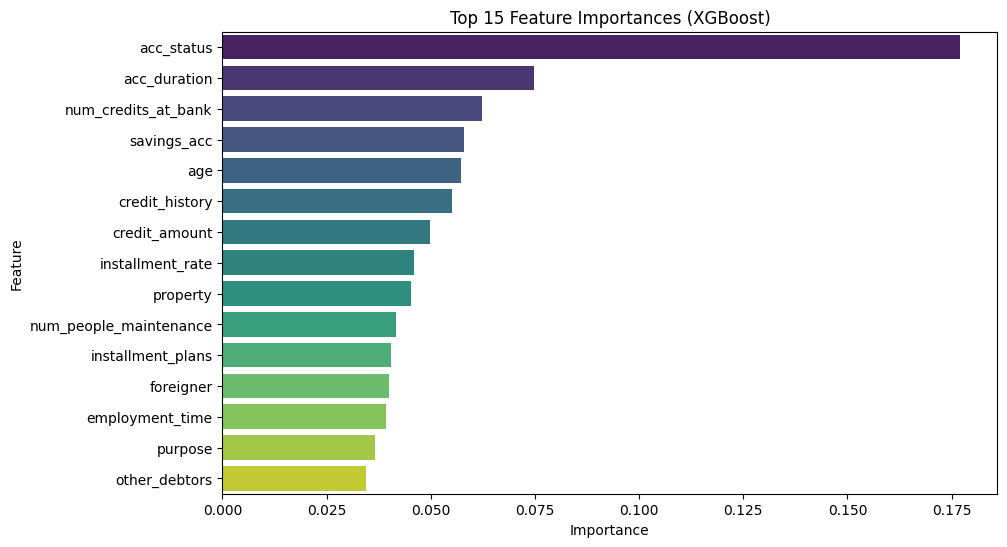

,Feature,Importance
0,acc_status,0.177130
1,acc_duration,0.074886
15,num_credits_at_bank,0.062292
5,savings_acc,0.058095
12,age,0.057314
2,credit_history,0.055051
4,credit_amount,0.049848
7,installment_rate,0.045989
11,property,0.045329
17,num_people_maintenance,0.041548


In [ ]:
importances = best_xgb.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()

feat_imp.head(15)


In [71]:
top_features = feat_imp['Feature'].head(15).tolist()

X_top15 = X[top_features]

print("Saxlanılan sütunlar:")
print(top_features)


Saxlanılan sütunlar:
['acc_status', 'acc_duration', 'num_credits_at_bank', 'savings_acc', 'age', 'credit_history', 'credit_amount', 'installment_rate', 'property', 'num_people_maintenance', 'installment_plans', 'foreigner', 'employment_time', 'purpose', 'other_debtors']


In [74]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_top15, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

In [75]:
xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.5],
    'reg_lambda': [1.0, 2.0]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',          
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n Best Parameters:", grid.best_params_)
print("Best Cross-Validated F1 Score:", grid.best_score_)


Fitting 5 folds for each of 576 candidates, totalling 2880 fits

 Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 0.8}
Best Cross-Validated F1 Score: 0.8535331378621389


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [05:04:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [76]:
best_xgb_imp = grid.best_estimator_

In [78]:
y_train_pred = best_xgb_imp.predict(X_train)
y_val_pred = best_xgb_imp.predict(X_val)
y_test_pred = best_xgb_imp.predict(X_test)

print(" Train Results:")
print("  Accuracy :", accuracy_score(y_train, y_train_pred))
print("  Precision:", precision_score(y_train, y_train_pred))
print("  F1 Score :", f1_score(y_train, y_train_pred))

print("\Validation Results:")
print("  Accuracy :", accuracy_score(y_val, y_val_pred))
print("  Precision:", precision_score(y_val, y_val_pred))
print("  F1 Score :", f1_score(y_val, y_val_pred))

print("\Test Results:")
print("  Accuracy :", accuracy_score(y_test, y_test_pred))
print("  Precision:", precision_score(y_test, y_test_pred))
print("  F1 Score :", f1_score(y_test, y_test_pred))

 Train Results:
  Accuracy : 0.928125
  Precision: 0.91701244813278
  F1 Score : 0.9505376344086022
\Validation Results:
  Accuracy : 0.71875
  Precision: 0.7768595041322314
  F1 Score : 0.8068669527896996
\Test Results:
  Accuracy : 0.79
  Precision: 0.831081081081081
  F1 Score : 0.8541666666666666


In [ ]:
#TREE model with train test split 
tree_model.fit(X_train, y_train)

y_val_pred_tree = tree_model.predict(X_val)
print("Validation Results:")
print("  Accuracy:", accuracy_score(y_val, y_val_pred_tree))
print("  Precision:", precision_score(y_val, y_val_pred_tree))
print("  F1:", f1_score(y_val, y_val_pred_tree))

y_test_pred_tree = tree_model.predict(X_test)
print("\nTest Results:")
print("  Accuracy:", accuracy_score(y_test, y_test_pred_tree))
print("  Precision:", precision_score(y_test, y_test_pred_tree))
print("  F1:", f1_score(y_test, y_test_pred_tree))

Validation Results:
  Accuracy: 0.575
  Precision: 0.75
  F1: 0.66

Test Results:
  Accuracy: 0.65
  Precision: 0.8240740740740741
  F1: 0.717741935483871


# GRID SEACRH TREE

In [65]:
tree_m = DecisionTreeClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=tree_m,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)


grid.fit(X_train, y_train)
print("\n Best Parameters:", grid.best_params_)
print("Best Cross-Validated F1 Score:", grid.best_score_)


Fitting 5 folds for each of 192 candidates, totalling 960 fits

 Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Cross-Validated F1 Score: 0.7703275452878027


In [66]:
best_tree = grid.best_estimator_

y_train_pred = best_tree.predict(X_train)
y_val_pred = best_tree.predict(X_val)
y_test_pred = best_tree.predict(X_test)


print("\n Train Results:")
print("  Accuracy :", accuracy_score(y_train, y_train_pred))
print("  Precision:", precision_score(y_train, y_train_pred))
print("  F1 Score :", f1_score(y_train, y_train_pred))

print("\n Validation Results:")
print("  Accuracy :", accuracy_score(y_val, y_val_pred))
print("  Precision:", precision_score(y_val, y_val_pred))
print("  F1 Score :", f1_score(y_val, y_val_pred))

print("\n Test Results:")
print("  Accuracy :", accuracy_score(y_test, y_test_pred))
print("  Precision:", precision_score(y_test, y_test_pred))
print("  F1 Score :", f1_score(y_test, y_test_pred))



 Train Results:
  Accuracy : 0.7578125
  Precision: 0.8906666666666667
  F1 Score : 0.8116646415552855

 Validation Results:
  Accuracy : 0.59375
  Precision: 0.7640449438202247
  F1 Score : 0.6766169154228856

 Test Results:
  Accuracy : 0.695
  Precision: 0.816
  F1 Score : 0.769811320754717


# GRID SEARCH RF

In [68]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)

grid.fit(X_train, y_train)
print("\nBest Parameters:", grid.best_params_)
print("Best Cross-Validated F1 Score:", grid.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best Cross-Validated F1 Score: 0.8358412317336171


In [69]:
best_rf = grid.best_estimator_

y_train_pred = best_rf.predict(X_train)
y_val_pred = best_rf.predict(X_val)
y_test_pred = best_rf.predict(X_test)

print("\n Train Results:")
print("  Accuracy :", accuracy_score(y_train, y_train_pred))
print("  Precision:", precision_score(y_train, y_train_pred))
print("  F1 Score :", f1_score(y_train, y_train_pred))

print("\n Validation Results:")
print("  Accuracy :", accuracy_score(y_val, y_val_pred))
print("  Precision:", precision_score(y_val, y_val_pred))
print("  F1 Score :", f1_score(y_val, y_val_pred))

print("\n Test Results:")
print("  Accuracy :", accuracy_score(y_test, y_test_pred))
print("  Precision:", precision_score(y_test, y_test_pred))
print("  F1 Score :", f1_score(y_test, y_test_pred))



 Train Results:
  Accuracy : 0.978125
  Precision: 0.9887387387387387
  F1 Score : 0.984304932735426

 Validation Results:
  Accuracy : 0.74375
  Precision: 0.8034188034188035
  F1 Score : 0.8209606986899564

 Test Results:
  Accuracy : 0.75
  Precision: 0.835820895522388
  F1 Score : 0.8175182481751825


In [ ]:
# TEESSUFKI OVERFITT